# PCA-component versus supervised-feature XGBoost comparison

This notebook tests whether the 95% PCA representation retains predictive signal for functional illiteracy. It reproduces Phase 1, then performs the train/test split *before* fitting PCA or selecting original features.

The primary comparison is between: (1) XGBoost trained on 95%-variance PCA component scores, and (2) XGBoost trained on the 44 highest-gain original features selected from the training set only.

Loading datasets...
Cleaning duplicate geographic columns before merging...
Merging datasets...
Final merged shape (Ages 10-64): (496770, 196)
--- STRINGS (Currently safe) ---
['MOTHER_LNO', 'FATHER_LNO', 'OF_PRESENT', 'ATTEND_SCHOOL', 'ATTEND_GRADE_LEVEL', 'ATTEND_GRADE', 'MODETRVL1', 'MODETRVL2', 'MODETRVL3', 'NATT_REASON', 'BASIC_LIT', 'BASIC_NUM', 'HGC_LEVEL', 'HGC_GRADE', 'DAYCARE', 'KINDER', 'SHS', 'SHS_TRACK', 'ALS', 'WORK', 'WORK_TYPE_MAJOR', 'WORK_CLASS', 'NOWORK_REASON', 'DIFF_SEEING', 'DIFF_HEARING', 'DIFF_WALKING', 'DIFF_REMEMBERING', 'DIFF_SELFCARE', 'DIFF_COMMUNICATING', 'ADULTS', 'GUARDIAN', 'TOILET_LOC', 'TOILET_SHARE', 'TOILET_PUBLIC', 'ODL_SOFTWARE', 'ODL_TECHNOLOGY', 'READ_IND_F2', 'HGC_GRADE_F2', 'READING59', 'WRITING59', 'COMPUTE59', 'LLEVEL59', 'READING', 'WRITING', 'COMPUTE', 'COMPRE', 'LLEVEL10OVER', 'LLEVEL5OVER', 'FLLEVEL', 'BLITERATE', 'FLITERATE', 'READ_IND_F3', 'MM_PNPAPER', 'MM_OLNPAPER', 'MM_MAGAZINE', 'MM_POSTERS', 'MM_TV', 'MM_RADIO', 'MM_MOVIES', 'MM_V

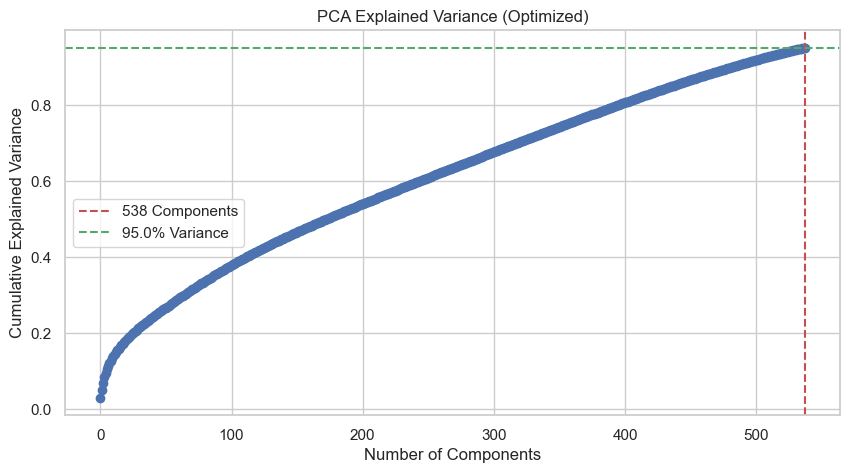


--- Top Features from Principal Components ---
Phase 1 Complete! Extracted 43 unique features.
Building dynamic dictionary from Excel files...
✅ Dictionary built successfully! Found 7354 codes.

✅ Saved 'phase1_selected_features.csv' with fully cleaned, thesis-ready labels!
Phase 1 complete: 496,770 rows and 750 encoded features.


In [1]:
# Re-run the existing Phase 1 cells only, so this notebook remains standalone.
# Cells 2-7 load the PSA data, preprocess it, fit the descriptive full-data PCA,
# and construct feature labels. Phase 1B and Phase 2 are deliberately excluded.
from pathlib import Path
import nbformat

SOURCE_NOTEBOOK = Path('PCA_FLEMMS_streamlined.ipynb')
if not SOURCE_NOTEBOOK.exists():
    raise FileNotFoundError(f'Expected {SOURCE_NOTEBOOK} beside this notebook.')

source_nb = nbformat.read(SOURCE_NOTEBOOK, as_version=4)
phase_1_code = '\n\n'.join(
    ''.join(cell.source)
    for cell in source_nb.cells[2:8]
    if cell.cell_type == 'code'
)
exec(compile(phase_1_code, str(SOURCE_NOTEBOOK), 'exec'), globals())

print(f'Phase 1 complete: {X_scaled.shape[0]:,} rows and {X_scaled.shape[1]:,} encoded features.')

In [2]:
import gc
from sklearn.decomposition import PCA
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

RANDOM_STATE = 42
TOP_FEATURES = 44
PCA_VARIANCE_THRESHOLD = 0.95
NEARLY_EQUIVALENT_AUC_GAP = 0.02

# The Phase 1 PCA was fit to all rows for EDA. Do not reuse it for this held-out
# comparison, and release its large score matrix before fitting train-only PCA.
del X_pca, pca_model
gc.collect()

y_raw = pd.to_numeric(df_merged['FLITERATE'], errors='coerce').to_numpy()
weights_raw = df_merged['RESP_RFACT_F2'].fillna(1.0).to_numpy()
valid_mask = ~np.isnan(y_raw)

X = X_scaled[valid_mask]
y = np.where(y_raw[valid_mask] == 2, 1, 0)  # 0 = Literate, 1 = Illiterate
weights = weights_raw[valid_mask]

row_indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    row_indices, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
w_train, w_test = weights[train_idx], weights[test_idx]

print(f'Train rows: {len(y_train):,}; test rows: {len(y_test):,}.')

Train rows: 374,914; test rows: 93,729.


In [3]:
def fit_xgboost(X_train_model, y_train_model, w_train_model):
    scale_pos_weight = (y_train_model == 0).sum() / (y_train_model == 1).sum()
    model = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
        eval_metric='auc', n_jobs=-1,
    )
    model.fit(X_train_model, y_train_model, sample_weight=w_train_model)
    return model

def evaluate_model(name, model, X_test_model):
    probabilities = model.predict_proba(X_test_model)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    return {
        'Model': name,
        'ROC_AUC': roc_auc_score(y_test, probabilities, sample_weight=w_test),
        'PR_AUC': average_precision_score(y_test, probabilities, sample_weight=w_test),
        'Balanced_Accuracy': balanced_accuracy_score(y_test, predictions, sample_weight=w_test),
        'Recall': recall_score(y_test, predictions, sample_weight=w_test, zero_division=0),
        'Precision': precision_score(y_test, predictions, sample_weight=w_test, zero_division=0),
        'F1': f1_score(y_test, predictions, sample_weight=w_test, zero_division=0),
    }

In [4]:
# Model A: fit PCA only on training rows, preserving 95% of their variance.
pca_train = PCA(n_components=PCA_VARIANCE_THRESHOLD, random_state=RANDOM_STATE)
X_train_pca = pca_train.fit_transform(X_train)
X_test_pca = pca_train.transform(X_test)

pca_xgb = fit_xgboost(X_train_pca, y_train, w_train)
pca_result = evaluate_model('PCA components (95% variance)', pca_xgb, X_test_pca)
pca_result['Input_Features'] = pca_train.n_components_
pca_result['Variance_Retained'] = pca_train.explained_variance_ratio_.sum()

print(f"PCA retained {pca_train.n_components_} components and {pca_result['Variance_Retained']:.2%} training variance.")

PCA retained 533 components and 95.05% training variance.


In [5]:
# Model B: choose original variables from training data only, then fit XGBoost.
selector = fit_xgboost(X_train, y_train, w_train)
train_gain = pd.Series(selector.feature_importances_, index=feature_names)
selected_features = train_gain.nlargest(TOP_FEATURES).index
selected_positions = feature_names.get_indexer(selected_features)

X_train_selected = X_train[:, selected_positions]
X_test_selected = X_test[:, selected_positions]
supervised_xgb = fit_xgboost(X_train_selected, y_train, w_train)
supervised_result = evaluate_model('Supervised original features', supervised_xgb, X_test_selected)
supervised_result['Input_Features'] = len(selected_features)
supervised_result['Variance_Retained'] = np.nan

selected_feature_report = pd.DataFrame({
    'Feature_Name': selected_features,
    'Training_Gain_Importance': train_gain.loc[selected_features].to_numpy(),
})
selected_feature_report.to_csv('pca_comparison_supervised_selected_features.csv', index=False)
print("Saved 'pca_comparison_supervised_selected_features.csv'.")

Saved 'pca_comparison_supervised_selected_features.csv'.


In [7]:
comparison = pd.DataFrame([pca_result, supervised_result])[
    ['Model', 'Input_Features', 'Variance_Retained', 'ROC_AUC', 'PR_AUC',
     'Balanced_Accuracy', 'Recall', 'Precision', 'F1']
]
comparison.to_csv('pca_component_xgboost_comparison.csv', index=False)
display(comparison.round(4))

auc_gap = supervised_result['ROC_AUC'] - pca_result['ROC_AUC']
if abs(auc_gap) <= NEARLY_EQUIVALENT_AUC_GAP:
    interpretation = (
        f'ROC-AUC gap = {auc_gap:+.4f}. Under the predeclared ±{NEARLY_EQUIVALENT_AUC_GAP:.2f} threshold, '
        'the PCA representation retains comparable predictive signal.'
    )
else:
    interpretation = (
        f'ROC-AUC gap = {auc_gap:+.4f}. It exceeds the predeclared ±{NEARLY_EQUIVALENT_AUC_GAP:.2f} threshold, '
        'indicating that variance-preserving PCA compression does not retain all outcome-relevant signal.'
    )

Path('pca_component_xgboost_interpretation.txt').write_text(interpretation, encoding='utf-8')
print("Saved 'pca_component_xgboost_comparison.csv'.")
print(interpretation)

,Model,Input_Features,Variance_Retained,ROC_AUC,PR_AUC,Balanced_Accuracy,Recall,Precision,F1
0,PCA components (95% variance),533,0.9505,0.7132,0.5305,0.6513,0.5928,0.4564,0.5157
1,Supervised original features,44,NaN,0.7020,0.5194,0.6460,0.5946,0.4469,0.5103


Saved 'pca_component_xgboost_comparison.csv'.
ROC-AUC gap = -0.0112. Under the predeclared ±0.02 threshold, the PCA representation retains comparable predictive signal.
